In [2]:
import pandas as pd
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
data = pd.read_csv("Cleaned_Dataset.csv")
data.head()

,Study_Hours,Attendance_Percentage,Internal_Assessment_Score,Previous_Academic_Result,Final_Grade,Study_Efficiency,Internet_Usage_Hours,Gender_Male,Result
0,6.7,74.9,41.4,83.8,75,0.67,6.5,1,1
1,9.6,73.3,41.9,76.4,40,0.74,5.8,0,0
2,7.6,67.0,40.1,60.8,60,0.77,4.1,1,1
3,6.4,84.3,49.5,79.8,75,0.85,5.6,1,1
4,2.4,80.7,33.4,76.4,60,0.93,2.7,1,1


In [4]:
X = data.drop('Final_Grade', axis=1)
y = data['Final_Grade']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[0.63333333 0.3725     0.53866667 0.73       0.34       0.78571429
  1.         1.        ]
 [0.95555556 0.3325     0.552      0.60666667 0.48       0.68571429
  0.         0.        ]
 [0.73333333 0.175      0.504      0.34666667 0.54       0.44285714
  1.         1.        ]
 [0.6        0.6075     0.75466667 0.66333333 0.7        0.65714286
  1.         1.        ]
 [0.15555556 0.5175     0.32533333 0.60666667 0.86       0.24285714
  1.         1.        ]]


In [5]:
X = data.drop('Final_Grade', axis=1)
y = data['Final_Grade']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

[[ 4.38155570e-01 -5.14075759e-01 -1.32784267e-03  6.57081958e-01
  -7.40735721e-01  9.69273163e-01  1.16984859e+00  5.95213847e-01]
 [ 1.64666516e+00 -6.66530865e-01  6.51973412e-02  2.15391932e-01
  -2.60780332e-01  5.99073294e-01 -8.54811479e-01 -1.68006844e+00]
 [ 8.13210270e-01 -1.26682284e+00 -1.74293321e-01 -7.15738393e-01
  -5.50851656e-02 -2.99983531e-01  1.16984859e+00  5.95213847e-01]
 [ 3.13137336e-01  3.81597989e-01  1.07638014e+00  4.18330592e-01
   4.93435279e-01  4.93301903e-01  1.16984859e+00  5.95213847e-01]
 [-1.35377244e+00  3.85740004e-02 -1.06573078e+00  2.15391932e-01
   1.04195572e+00 -1.04038327e+00  1.16984859e+00  5.95213847e-01]]


In [6]:
# Binary Classification
data['Result'] = data['Final_Grade'].apply(lambda x: 1 if x >= 50 else 0)

# Label
data['Result_Label'] = data['Result'].map({1: 'Pass', 0: 'Fail'})

# Grade Label
data['Grade_Label'] = data['Final_Grade'].apply(
    lambda x: 'A' if x >= 85 else
              'B' if x >= 75 else
              'C' if x >= 60 else
              'D' if x >= 40 else
              'F'
)

In [7]:
data.head(5)

,Study_Hours,Attendance_Percentage,Internal_Assessment_Score,Previous_Academic_Result,Final_Grade,Study_Efficiency,Internet_Usage_Hours,Gender_Male,Result,Result_Label,Grade_Label
0,6.7,74.9,41.4,83.8,75,0.67,6.5,1,1,Pass,B
1,9.6,73.3,41.9,76.4,40,0.74,5.8,0,0,Fail,D
2,7.6,67.0,40.1,60.8,60,0.77,4.1,1,1,Pass,C
3,6.4,84.3,49.5,79.8,75,0.85,5.6,1,1,Pass,B
4,2.4,80.7,33.4,76.4,60,0.93,2.7,1,1,Pass,C


In [8]:
X = data.drop(['Final_Grade', 'Result', 'Result_Label', 'Grade_Label'], axis=1)
y = data['Final_Grade']

In [9]:
model = LinearRegression()
fs_forward = SequentialFeatureSelector(model,n_features_to_select=3,direction='forward')

In [10]:
fs_forward.fit(X, y)

SequentialFeatureSelector(estimator=LinearRegression(), n_features_to_select=3)

In [11]:
forward_features = X.columns[fs_forward.get_support()]
print("Forward Selected Features:")
print(list(forward_features))

Forward Selected Features:
['Study_Hours', 'Internal_Assessment_Score', 'Previous_Academic_Result']


In [12]:
model = LinearRegression()
fs_backward = SequentialFeatureSelector(model,n_features_to_select=3,direction='backward')

In [13]:
fs_backward.fit(X, y)

SequentialFeatureSelector(direction='backward', estimator=LinearRegression(),
                          n_features_to_select=3)

In [14]:
backward_features = X.columns[fs_backward.get_support()]
print("Backward Selected Features:")
print(list(backward_features))

Backward Selected Features:
['Study_Hours', 'Internal_Assessment_Score', 'Previous_Academic_Result']


In [15]:
X = data.drop(['Final_Grade', 'Result', 'Result_Label', 'Grade_Label'], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)

import numpy as np
cumulative_variance = np.cumsum(explained_variance)
print("Cumulative Variance:", cumulative_variance)

n_components = np.argmax(cumulative_variance >= 0.95) + 1
print("Number of components (95% variance):", n_components)

pca_final = PCA(n_components=n_components)
X_pca = pca_final.fit_transform(X_scaled)

# Convert to DataFrame
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])

print(X_pca_df.head())

Explained Variance Ratio: [0.24198118 0.14783847 0.14499264 0.14296555 0.14228207 0.13755156
 0.04238851]
Cumulative Variance: [0.24198118 0.38981965 0.5348123  0.67777785 0.82005992 0.95761149
 1.        ]
Number of components (95% variance): 6
        PC1       PC2       PC3       PC4       PC5       PC6
0  0.509249  1.053683 -0.342565 -0.357489 -0.387034  1.326437
1  0.952452 -0.751710 -1.063289  0.612307  0.475291  0.712888
2 -0.172622 -0.413547  0.013054  0.554720 -1.363440  1.378217
3  1.146199  0.870036  0.943476  0.210135 -0.142568  0.531178
4 -1.379948  0.865439  1.131725  0.189988 -1.298668 -0.926625


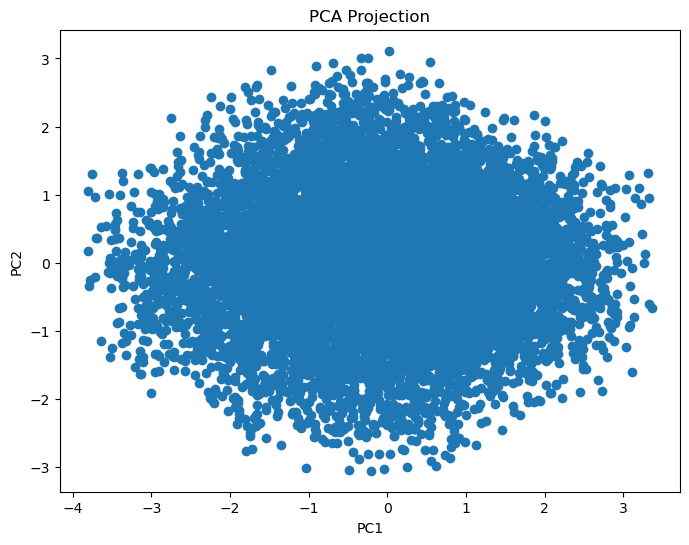

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca_df.iloc[:,0], X_pca_df.iloc[:,1])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title("PCA Projection")
plt.show()

In [17]:
data.to_csv("processed_data.csv", index=False)

In [18]:
X_pca_df.to_csv("pca_data.csv", index=False)